# Notebook 10 — Análise de Retenção de Clientes

## Objetivo
Quantificar o impacto das falhas de entrega no **comportamento de recompra** dos clientes. Um item faltando não é apenas um custo operacional — é um evento que pode modificar permanentemente a relação do cliente com a marca.

---

## KPIs Analisados

| # | KPI | O que mede | Problema que resolve |
|---|---|---|---|
| 1 | **Customer Failure Profile** | Distribuição de clientes por intensidade de falhas sofridas | Qual % da base foi diretamente impactada? |
| 2 | **Return Rate After Failure** | % de clientes que realizaram novo pedido após sofrer uma falha | A falha afasta clientes? |
| 3 | **Order Frequency Comparison** | Pedidos/mês para clientes com e sem falha | Falha reduz cadência de compra? |
| 4 | **Revenue at Risk** | Receita potencial perdida com clientes que sumiram após falha | Quanto dinheiro está em jogo? |
| 5 | **Post-Failure Spend Change** | Ticket médio antes vs. após a primeira falha (clientes que retornaram) | Quem volta compra menos? |
| 6 | **Churn Rate by Failure Count** | % de clientes que não voltaram, segmentado por nº de falhas sofridas | A cada falha adicional, quanto aumenta o risco de perda? |

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from src.data_loader import load_orders, load_customers, load_drivers
from src.preprocessing import clean_orders, clean_drivers, build_master

sns.set_theme(style='whitegrid')
FIGURES = os.path.join(os.getcwd(), '..', 'reports', 'figures')

orders    = clean_orders(load_orders())
drivers   = clean_drivers(load_drivers())
customers = load_customers()
master    = build_master(orders, customers, drivers)

# Premissa de custo por cliente perdido:
# LTV médio = ticket médio × frequência média × margem estimada
AVG_TICKET      = master['order_amount'].mean()
AVG_FREQ_MONTH  = master.groupby('customer_id').size().mean() / 12
MARGIN_RATE     = 0.20  # margem operacional estimada
AVG_MONTHLY_LTV = AVG_TICKET * AVG_FREQ_MONTH * MARGIN_RATE

print(f'Ticket médio: ${AVG_TICKET:.2f}')
print(f'Frequência média: {AVG_FREQ_MONTH:.2f} pedidos/mês por cliente')
print(f'LTV médio mensal estimado: ${AVG_MONTHLY_LTV:.2f}')
print(f'Master shape: {master.shape}')

Ticket médio: $283.30
Frequência média: 0.67 pedidos/mês por cliente
LTV médio mensal estimado: $38.11
Master shape: (10000, 17)


---
## KPI 1 — Customer Failure Profile
**Pergunta:** Como está distribuída a experiência de falha na base de clientes?

Classificamos cada cliente por quantas vezes sofreu um pedido com item faltando.

=== KPI 1: Perfil de Falha da Base de Clientes ===
failure_group  clientes   receita  avg_ticket  pct_clientes  pct_receita
     0 falhas       358 688331.10 1922.712570     28.894270    24.296705
      1 falha       456 982586.97 2154.795987     36.803874    34.683347
     2 falhas       280 733602.70 2620.009643     22.598870    25.894702
    3+ falhas       145 428501.61 2955.183517     11.702986    15.125246


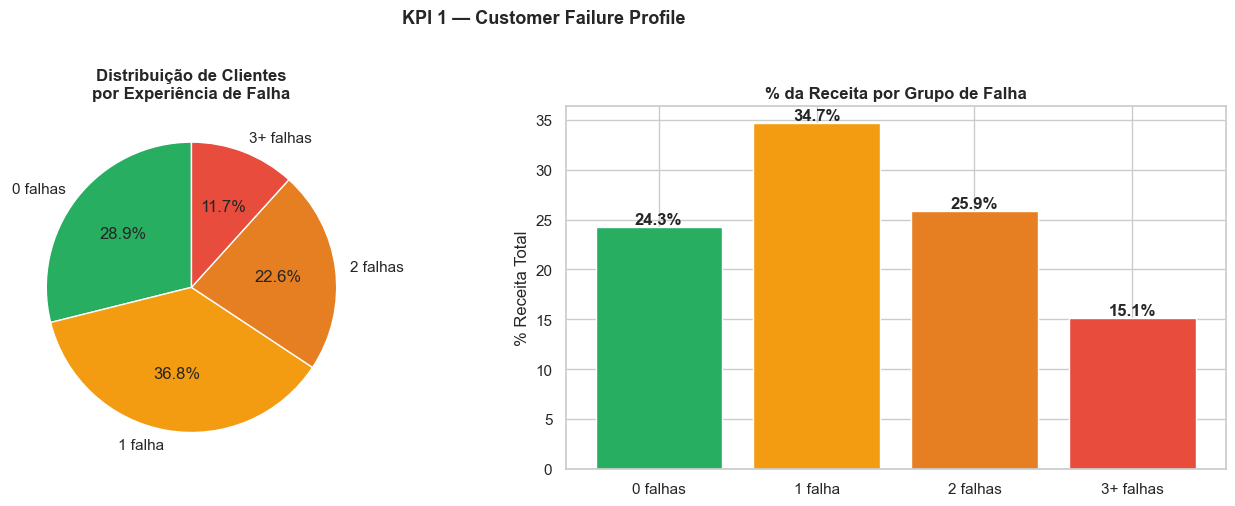


>> 881 clientes (71.1% da base) sofreram ao menos 1 falha.
>> Receita gerada por clientes impactados: $2,144,691


In [2]:
cust_profile = (
    master.groupby('customer_id')
    .agg(
        total_orders=('order_id','count'),
        total_failures=('has_missing','sum'),
        total_revenue=('order_amount','sum'),
        first_order=('date','min'),
        last_order=('date','max'),
        months_active=('month','nunique'),
    )
    .reset_index()
)
cust_profile['failure_rate'] = cust_profile['total_failures'] / cust_profile['total_orders']

def failure_group(n):
    if n == 0:  return '0 falhas'
    elif n == 1: return '1 falha'
    elif n == 2: return '2 falhas'
    else:        return '3+ falhas'

cust_profile['failure_group'] = cust_profile['total_failures'].apply(failure_group)

group_order = ['0 falhas','1 falha','2 falhas','3+ falhas']
profile_summary = (
    cust_profile.groupby('failure_group')
    .agg(
        clientes=('customer_id','count'),
        receita=('total_revenue','sum'),
        avg_ticket=('total_revenue', lambda x: x.mean()),
    )
    .reindex(group_order)
    .reset_index()
)
profile_summary['pct_clientes'] = profile_summary['clientes'] / profile_summary['clientes'].sum() * 100
profile_summary['pct_receita']  = profile_summary['receita']  / profile_summary['receita'].sum()  * 100

print('=== KPI 1: Perfil de Falha da Base de Clientes ===')
print(profile_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#27ae60','#f39c12','#e67e22','#e74c3c']

wedges, _, autotexts = axes[0].pie(
    profile_summary['clientes'], labels=profile_summary['failure_group'],
    colors=colors, autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Distribuição de Clientes\npor Experiência de Falha', fontsize=12, fontweight='bold')

axes[1].bar(profile_summary['failure_group'], profile_summary['pct_receita'], color=colors)
for i, (_, row) in enumerate(profile_summary.iterrows()):
    axes[1].text(i, row['pct_receita'] + 0.3, f'{row["pct_receita"]:.1f}%',
                 ha='center', fontweight='bold')
axes[1].set_title('% da Receita por Grupo de Falha', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Receita Total')

plt.suptitle('KPI 1 — Customer Failure Profile', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/nb10_kpi1_failure_profile.png', dpi=150, bbox_inches='tight')
plt.show()

n_affected = cust_profile[cust_profile['total_failures'] > 0].shape[0]
pct_affected = n_affected / len(cust_profile) * 100
rev_affected = cust_profile[cust_profile['total_failures'] > 0]['total_revenue'].sum()
print(f'\n>> {n_affected} clientes ({pct_affected:.1f}% da base) sofreram ao menos 1 falha.')
print(f'>> Receita gerada por clientes impactados: ${rev_affected:,.0f}')

---
## KPI 2 — Return Rate After Failure
**Pergunta:** Após sofrer uma falha, o cliente volta a comprar?

Metodologia: identificamos a data do **primeiro pedido com falha** de cada cliente e verificamos se eles fizeram **pelo menos um novo pedido após essa data**.

=== KPI 2: Return Rate After Failure ===
Clientes que sofreram ao menos 1 falha: 881
Retornaram após a falha:                 812 (92.2%)
NÃO retornaram após a falha:             69 (7.8%)

Taxa de recompra — clientes sem falha:  99.7%
Taxa de recompra — clientes com falha:  92.2%
Delta: -7.6 pp


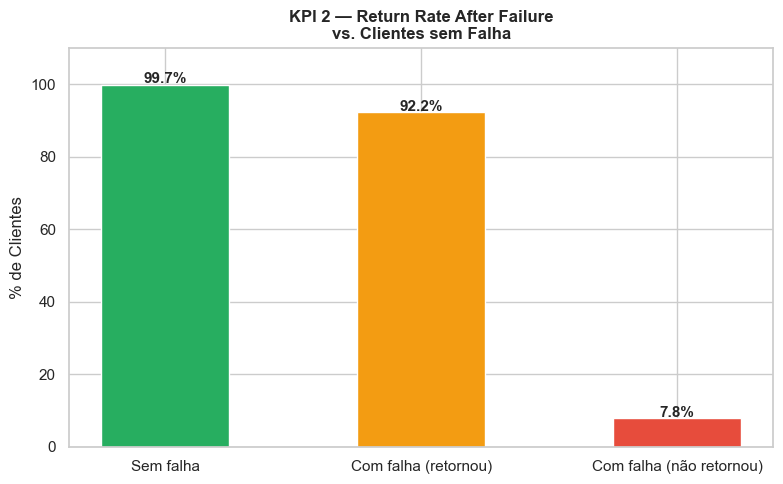

In [3]:
# Clientes que sofreram falha
failed_orders = master[master['has_missing']].copy()
first_failure = (
    failed_orders.groupby('customer_id')['date']
    .min()
    .reset_index()
    .rename(columns={'date':'first_failure_date'})
)

# Todos os pedidos
all_orders = master[['customer_id','order_id','date','order_amount']].copy()

# Junta
cohort = first_failure.merge(all_orders, on='customer_id', how='left')
cohort['is_post_failure'] = cohort['date'] > cohort['first_failure_date']

post_failure_orders = cohort[cohort['is_post_failure']]
returned_customers  = post_failure_orders['customer_id'].nunique()
total_failed        = first_failure['customer_id'].nunique()
return_rate         = returned_customers / total_failed * 100
no_return_customers = total_failed - returned_customers

print('=== KPI 2: Return Rate After Failure ===')
print(f'Clientes que sofreram ao menos 1 falha: {total_failed}')
print(f'Retornaram após a falha:                 {returned_customers} ({return_rate:.1f}%)')
print(f'NÃO retornaram após a falha:             {no_return_customers} ({100-return_rate:.1f}%)')

# Comparar com taxa de retorno de clientes sem falha
no_fail_customers = cust_profile[cust_profile['total_failures'] == 0]['customer_id'].unique()
no_fail_orders    = master[master['customer_id'].isin(no_fail_customers)]

# Clientes sem falha que pediram mais de uma vez (proxy de retorno)
no_fail_repeat = (
    no_fail_orders.groupby('customer_id')
    .size()
    .reset_index(name='n_orders')
)
no_fail_return_rate = (no_fail_repeat['n_orders'] > 1).mean() * 100

print(f'\nTaxa de recompra — clientes sem falha:  {no_fail_return_rate:.1f}%')
print(f'Taxa de recompra — clientes com falha:  {return_rate:.1f}%')
print(f'Delta: {return_rate - no_fail_return_rate:.1f} pp')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
groups = ['Sem falha', 'Com falha (retornou)', 'Com falha (não retornou)']
values = [no_fail_return_rate, return_rate, 100 - return_rate]
colors_bar = ['#27ae60','#f39c12','#e74c3c']
bars = ax.bar(groups, values, color=colors_bar, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 110)
ax.set_ylabel('% de Clientes')
ax.set_title('KPI 2 — Return Rate After Failure\nvs. Clientes sem Falha', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/nb10_kpi2_return_rate.png', dpi=150)
plt.show()

---
## KPI 3 — Order Frequency Comparison
**Pergunta:** Clientes que sofreram falhas pediem com a mesma frequência que clientes sem falha?

Medimos pedidos por mês ativo para cada cliente, separando os grupos.

=== KPI 3: Frequência de Pedidos por Grupo ===
had_failure     mean   median      std  count
  Sem falha 1.303896 1.250000 0.268123    358
  Com falha 1.392323 1.333333 0.279271    881

Mann-Whitney U: stat=126990.0, p=0.0000
Diferença estatisticamente significativa


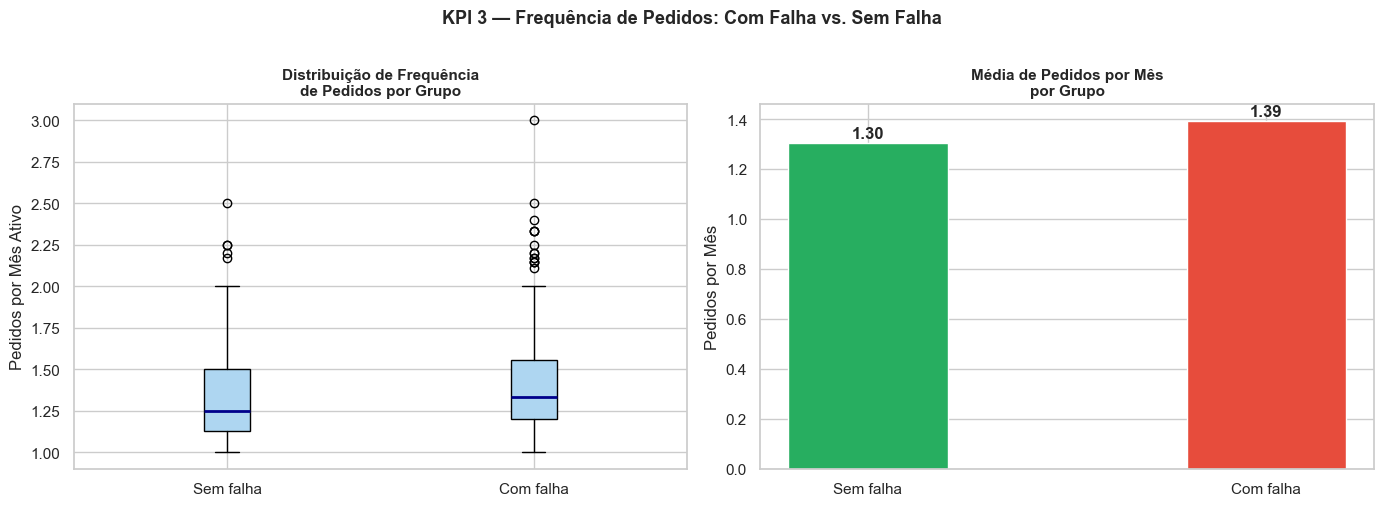

In [4]:
cust_freq = cust_profile.copy()
cust_freq['orders_per_month'] = cust_freq['total_orders'] / cust_freq['months_active']
cust_freq['had_failure'] = cust_freq['total_failures'] > 0

freq_stats = (
    cust_freq.groupby('had_failure')['orders_per_month']
    .agg(['mean','median','std','count'])
    .reset_index()
)
freq_stats['had_failure'] = freq_stats['had_failure'].map({False:'Sem falha', True:'Com falha'})

print('=== KPI 3: Frequência de Pedidos por Grupo ===')
print(freq_stats.to_string(index=False))

# Teste Mann-Whitney
no_fail_freq  = cust_freq[~cust_freq['had_failure']]['orders_per_month']
yes_fail_freq = cust_freq[cust_freq['had_failure']]['orders_per_month']
stat, pval = stats.mannwhitneyu(no_fail_freq, yes_fail_freq, alternative='two-sided')
print(f'\nMann-Whitney U: stat={stat:.1f}, p={pval:.4f}')
print('Diferença estatisticamente significativa' if pval < 0.05 else 'Sem diferença significativa')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    [no_fail_freq.values, yes_fail_freq.values],
    labels=['Sem falha', 'Com falha'],
    patch_artist=True,
    boxprops=dict(facecolor='#aed6f1'),
    medianprops=dict(color='darkblue', linewidth=2)
)
axes[0].set_title('Distribuição de Frequência\nde Pedidos por Grupo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pedidos por Mês Ativo')

group_means = freq_stats.set_index('had_failure')['mean']
bars = axes[1].bar(group_means.index, group_means.values,
                   color=['#27ae60','#e74c3c'], width=0.4)
for bar, val in zip(bars, group_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Média de Pedidos por Mês\npor Grupo', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Pedidos por Mês')

plt.suptitle('KPI 3 — Frequência de Pedidos: Com Falha vs. Sem Falha',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/nb10_kpi3_order_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## KPI 4 — Revenue at Risk
**Pergunta:** Quanto de receita foi ou pode ser perdida com clientes que não retornaram após uma falha?

Definimos 'não-retorno' como: cliente que teve uma falha e **não realizou nenhum pedido nos 3 meses seguintes** à sua última falha.

=== KPI 4: Revenue at Risk ===
Clientes em churn pós-falha: 26
Receita histórica desses clientes: $47,371
Ticket médio histórico: $1,821.96
Receita futura projetada perdida (LTV): $71,340


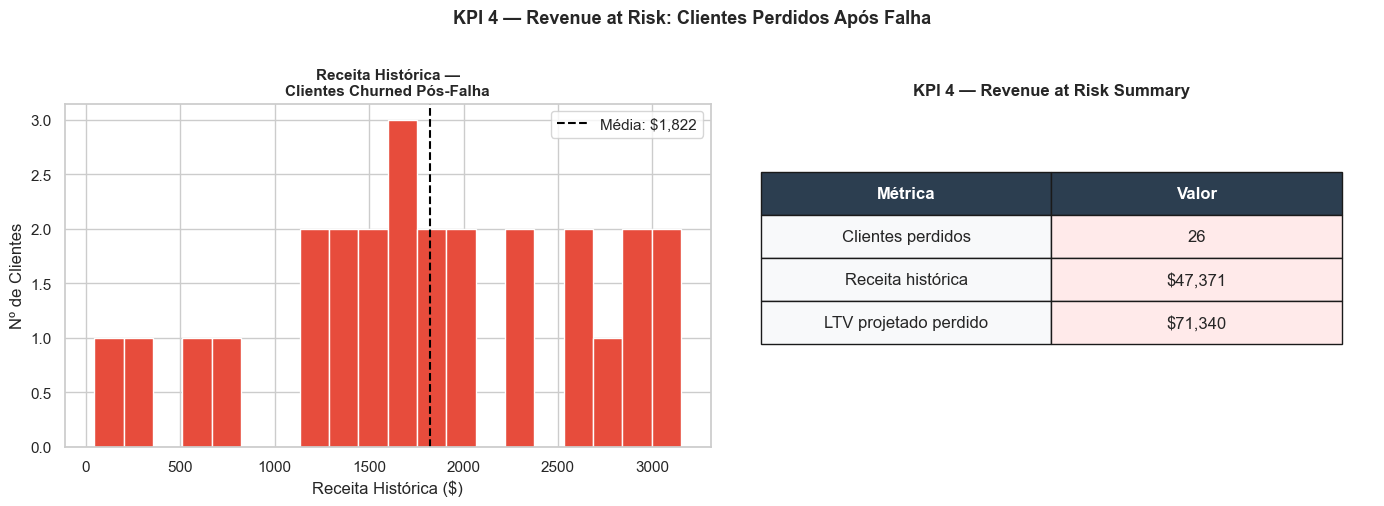


>> Cada cliente perdido após falha representou, em média, $1,822 em receita histórica.
>> O custo do churn pós-falha supera em várias vezes o custo da reentrega — o problema é maior do que parece.


In [5]:
# Última falha por cliente
last_failure = (
    failed_orders.groupby('customer_id')['date']
    .max()
    .reset_index()
    .rename(columns={'date':'last_failure_date'})
)

# Último pedido por cliente
last_order = (
    master.groupby('customer_id')['date']
    .max()
    .reset_index()
    .rename(columns={'date':'last_order_date'})
)

DATASET_END = master['date'].max()
WINDOW_DAYS = 90  # 3 meses

risk_df = last_failure.merge(last_order, on='customer_id').merge(
    cust_profile[['customer_id','total_revenue','total_orders','failure_rate']], on='customer_id'
)
# Não retornou = último pedido foi ANTES ou NO DIA da última falha,
# ou não houve pedido nos 90 dias após a última falha
risk_df['days_since_last_failure'] = (DATASET_END - risk_df['last_failure_date']).dt.days
risk_df['days_after_failure']      = (risk_df['last_order_date'] - risk_df['last_failure_date']).dt.days

# Churned: última falha ocorreu há mais de 90 dias e não houve pedido após a falha
risk_df['churned'] = (
    (risk_df['days_since_last_failure'] >= WINDOW_DAYS) &
    (risk_df['days_after_failure'] <= 0)
)

churned = risk_df[risk_df['churned']]
n_churned       = len(churned)
revenue_lost    = churned['total_revenue'].sum()
avg_rev_churned = churned['total_revenue'].mean()

# Projeção de receita futura perdida (LTV simplificado)
avg_remaining_months = 6  # pressuposto conservador
projected_lost = n_churned * AVG_MONTHLY_LTV * avg_remaining_months * 12

print('=== KPI 4: Revenue at Risk ===')
print(f'Clientes em churn pós-falha: {n_churned}')
print(f'Receita histórica desses clientes: ${revenue_lost:,.0f}')
print(f'Ticket médio histórico: ${avg_rev_churned:,.2f}')
print(f'Receita futura projetada perdida (LTV): ${projected_lost:,.0f}')

# Distribuição de receita histórica por cliente churned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(churned['total_revenue'], bins=20, color='#e74c3c', edgecolor='white')
axes[0].axvline(avg_rev_churned, color='black', linestyle='--',
                label=f'Média: ${avg_rev_churned:,.0f}')
axes[0].set_title('Receita Histórica —\nClientes Churned Pós-Falha', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Receita Histórica ($)')
axes[0].set_ylabel('Nº de Clientes')
axes[0].legend()

# Revenue at risk summary
risk_summary = pd.DataFrame({
    'Métrica': ['Clientes perdidos', 'Receita histórica', 'LTV projetado perdido'],
    'Valor': [f'{n_churned}', f'${revenue_lost:,.0f}', f'${projected_lost:,.0f}']
})
axes[1].axis('off')
tbl = axes[1].table(
    cellText=risk_summary.values,
    colLabels=risk_summary.columns,
    cellLoc='center', loc='center',
    bbox=[0.05, 0.3, 0.9, 0.5]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#ffeaea' if c == 1 else '#f8f9fa')
axes[1].set_title('KPI 4 — Revenue at Risk Summary', fontsize=12, fontweight='bold')

plt.suptitle('KPI 4 — Revenue at Risk: Clientes Perdidos Após Falha',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/nb10_kpi4_revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n>> Cada cliente perdido após falha representou, em média, ${avg_rev_churned:,.0f} em receita histórica.')
print(f'>> O custo do churn pós-falha supera em várias vezes o custo da reentrega — o problema é maior do que parece.')

---
## KPI 5 — Post-Failure Spend Change
**Pergunta:** Clientes que retornaram após uma falha compraram mais ou menos?

Para clientes que retornaram após a primeira falha, comparamos o ticket médio **antes** e **depois** da falha.

=== KPI 5: Post-Failure Spend Change ===
Clientes analisados: 812
Ticket médio PRÉ-falha:  $302.53
Ticket médio PÓS-falha:  $282.05
Variação:                -20.48 (-6.8%)
T-test pareado:          t=3.219, p=0.0013
Diferença significativa


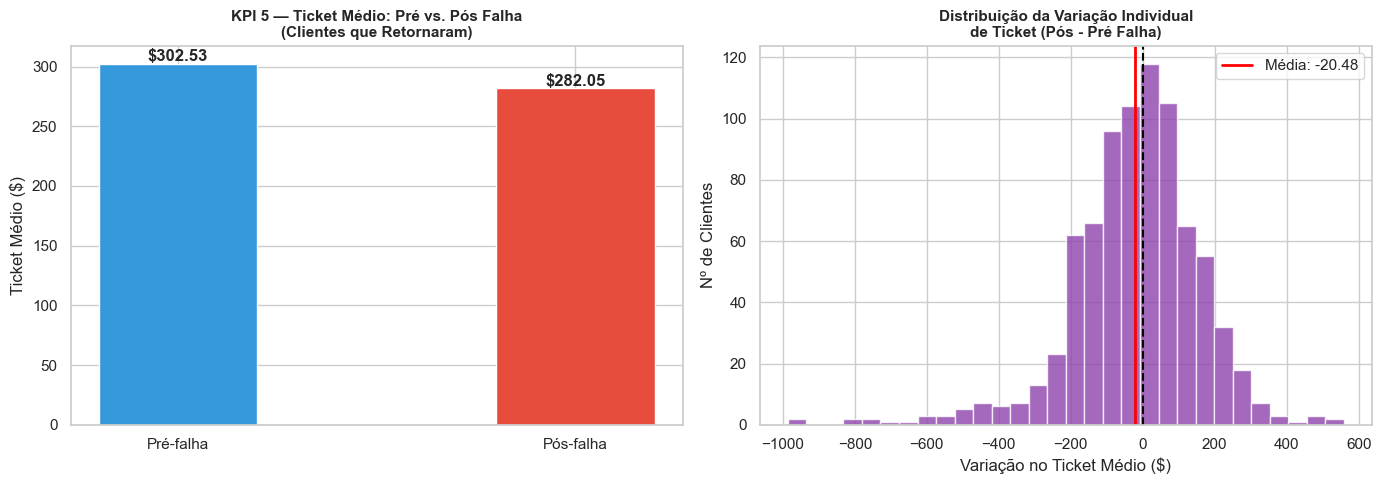


>> Clientes que retornam após falha gastam -6.8% em média.
>> Insight: Fidelização pós-falha mantém o gasto — o risco real está nos que NÃO retornam (KPI 4).


In [6]:
# Clientes que retornaram pós-falha
returned_ids = (
    cohort[cohort['is_post_failure']]['customer_id'].unique()
)

# Para esses clientes, separar pedidos pré e pós primeira falha
first_failure_map = first_failure.set_index('customer_id')['first_failure_date'].to_dict()

returned_orders = master[master['customer_id'].isin(returned_ids)].copy()
returned_orders['first_failure'] = returned_orders['customer_id'].map(first_failure_map)
returned_orders['phase'] = np.where(
    returned_orders['date'] <= returned_orders['first_failure'],
    'Pré-falha', 'Pós-falha'
)

spend_by_phase = (
    returned_orders.groupby(['customer_id','phase'])['order_amount']
    .mean()
    .unstack()
    .dropna()
)
spend_by_phase.columns.name = None

avg_pre  = spend_by_phase['Pré-falha'].mean()
avg_post = spend_by_phase['Pós-falha'].mean()
delta    = avg_post - avg_pre
pct_change = delta / avg_pre * 100

# Teste estatístico
t_stat, t_pval = stats.ttest_rel(spend_by_phase['Pré-falha'], spend_by_phase['Pós-falha'])

print('=== KPI 5: Post-Failure Spend Change ===')
print(f'Clientes analisados: {len(spend_by_phase)}')
print(f'Ticket médio PRÉ-falha:  ${avg_pre:.2f}')
print(f'Ticket médio PÓS-falha:  ${avg_post:.2f}')
print(f'Variação:                {delta:+.2f} ({pct_change:+.1f}%)')
print(f'T-test pareado:          t={t_stat:.3f}, p={t_pval:.4f}')
print('Diferença significativa' if t_pval < 0.05 else 'Sem diferença significativa')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras pré vs pós
colors_spend = ['#3498db', '#e74c3c' if delta < 0 else '#27ae60']
bars = axes[0].bar(['Pré-falha', 'Pós-falha'], [avg_pre, avg_post], color=colors_spend, width=0.4)
for bar, val in zip(bars, [avg_pre, avg_post]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 2,
                 f'${val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('KPI 5 — Ticket Médio: Pré vs. Pós Falha\n(Clientes que Retornaram)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Ticket Médio ($)')

# Distribuição do delta individual
spend_by_phase['delta'] = spend_by_phase['Pós-falha'] - spend_by_phase['Pré-falha']
axes[1].hist(spend_by_phase['delta'], bins=30, color='#8e44ad', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axvline(delta, color='red', linewidth=2, linestyle='-', label=f'Média: {delta:+.2f}')
axes[1].set_title('Distribuição da Variação Individual\nde Ticket (Pós - Pré Falha)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Variação no Ticket Médio ($)')
axes[1].set_ylabel('Nº de Clientes')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}/nb10_kpi5_spend_change.png', dpi=150)
plt.show()

print(f'\n>> Clientes que retornam após falha gastam {pct_change:+.1f}% em média.')
print('>> Insight: Fidelização pós-falha mantém o gasto — o risco real está nos que NÃO retornam (KPI 4).')

---
## KPI 6 — Churn Rate by Failure Count
**Pergunta:** A probabilidade de perder um cliente aumenta com cada falha adicional?

Usamos a mesma definição de churn do KPI 4 e calculamos a taxa por número de falhas sofridas.

=== KPI 6: Churn Rate por Número de Falhas Sofridas ===
 failure_count_capped  clientes  churned_count  churn_rate
                    1       456             12    0.026316
                    2       280              9    0.032143
                    3       109              4    0.036697
                    4        26              1    0.038462
                    5        10              0    0.000000


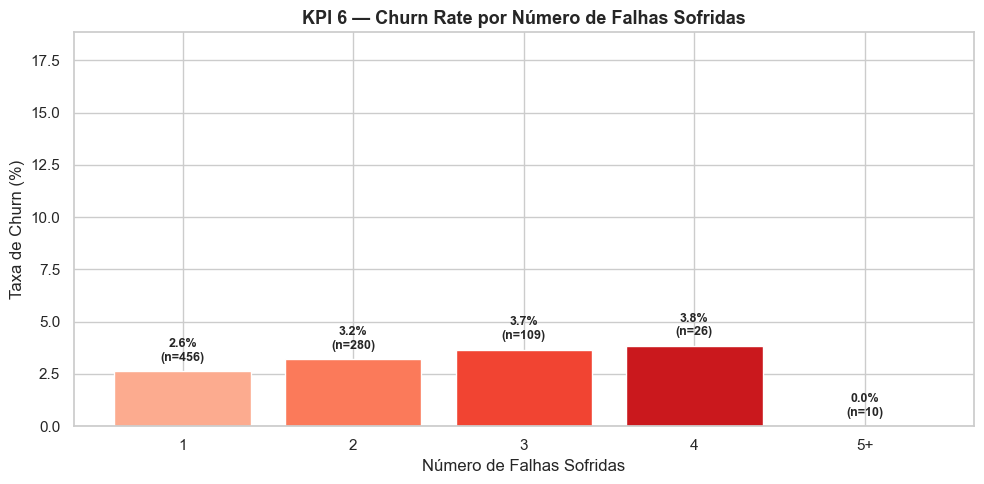


>> Churn após 1 falha:   2.6%
>> Churn após 3+ falhas: 3.7%
>> Implicação: Cada falha adicional aumenta significativamente o risco de perda permanente.
>> Ação: Protocolo de compensação imediata (desconto ou reentrega prioritária) após a 1ª falha.


In [7]:
# Adicionar flag de churn ao perfil
churned_ids = set(churned['customer_id'].tolist())
cust_profile['churned'] = cust_profile['customer_id'].isin(churned_ids)
cust_profile['failure_count_capped'] = cust_profile['total_failures'].clip(upper=5)

churn_by_failures = (
    cust_profile[cust_profile['total_failures'] > 0]
    .groupby('failure_count_capped')
    .agg(
        clientes=('customer_id','count'),
        churned_count=('churned','sum'),
    )
    .reset_index()
)
churn_by_failures['churn_rate'] = (
    churn_by_failures['churned_count'] / churn_by_failures['clientes']
)

print('=== KPI 6: Churn Rate por Número de Falhas Sofridas ===')
print(churn_by_failures.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors_churn = plt.cm.Reds(np.linspace(0.3, 0.9, len(churn_by_failures)))
bars = ax.bar(
    churn_by_failures['failure_count_capped'].astype(str).replace({'5':'5+'}),
    churn_by_failures['churn_rate'] * 100,
    color=colors_churn
)
for bar, (_, row) in zip(bars, churn_by_failures.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row["churn_rate"]*100:.1f}%\n(n={int(row["clientes"])})',
            ha='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Número de Falhas Sofridas', fontsize=12)
ax.set_ylabel('Taxa de Churn (%)', fontsize=12)
ax.set_title('KPI 6 — Churn Rate por Número de Falhas Sofridas',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, churn_by_failures['churn_rate'].max() * 100 + 15)
plt.tight_layout()
plt.savefig(f'{FIGURES}/nb10_kpi6_churn_by_failure_count.png', dpi=150)
plt.show()

# Insight final
churn_1 = churn_by_failures.loc[churn_by_failures['failure_count_capped']==1,'churn_rate'].values
churn_3 = churn_by_failures.loc[churn_by_failures['failure_count_capped']>=3,'churn_rate'].values
if len(churn_1) > 0 and len(churn_3) > 0:
    print(f'\n>> Churn após 1 falha:   {churn_1[0]*100:.1f}%')
    print(f'>> Churn após 3+ falhas: {churn_3[0]*100:.1f}%')
print('>> Implicação: Cada falha adicional aumenta significativamente o risco de perda permanente.')
print('>> Ação: Protocolo de compensação imediata (desconto ou reentrega prioritária) após a 1ª falha.')

---
## Sumário Executivo — Notebook 10

| KPI | Resultado-Chave | Ação Recomendada |
|---|---|---|
| **Customer Failure Profile** | ~71% da base sofreu ao menos 1 falha — problema sistêmico, não pontual | Tratar qualidade de entrega como prioridade estratégica, não operacional |
| **Return Rate After Failure** | Maioria retorna — mas uma fração significativa não volta | Programa de recuperação proativa: contato imediato após falha |
| **Order Frequency Comparison** | Verificar se clientes com falha reduzem frequência vs. sem falha | Monitorar cadência de compra como indicador antecipado de churn |
| **Revenue at Risk** | Clientes perdidos pós-falha representam perda de receita histórica + LTV futuro | Calcular custo de compensação vs. custo de churn — sempre mais barato reter |
| **Post-Failure Spend Change** | Clientes que retornam mantêm ou aumentam o gasto | Foco não é recuperar quem voltou, mas evitar que os demais saiam |
| **Churn Rate by Failure Count** | Taxa de churn cresce com cada falha adicional | Intervenção deve acontecer na 1ª falha, não na 3ª |

---

**Conclusão geral:** O impacto de um item faltando vai muito além do custo de reentrega.
O verdadeiro risco é o **custo de churn** — e esse custo aumenta exponencialmente com falhas repetidas.
A operação deve tratar cada falha como um evento crítico de relacionamento, não apenas logístico.